![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Importación de librerías
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz

In [7]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [9]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [10]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

In [11]:
#Datos balanceados
counts=bikes.groupby('season').size()
porcentaje=(counts/counts.sum())*100
print(porcentaje)
print('\n')

conteo_hour=bikes.groupby('hour').size()
porcentaje_hour=(conteo_hour/conteo_hour.sum())*100
print(porcentaje_hour)

season
1    24.673893
2    25.105640
3    25.105640
4    25.114826
dtype: float64


hour
0     4.179680
1     4.170494
2     4.115378
3     3.977586
4     4.060261
5     4.152122
6     4.179680
7     4.179680
8     4.179680
9     4.179680
10    4.179680
11    4.179680
12    4.188866
13    4.188866
14    4.188866
15    4.188866
16    4.188866
17    4.188866
18    4.188866
19    4.188866
20    4.188866
21    4.188866
22    4.188866
23    4.188866
dtype: float64


### Punto 1- ANÁLISIS DESCRIPTIVO
En ambos casos se cuenta con data balanceada. 
Season: Se observa que la demanda de bicicletas es estacional, existe una correlación. En la estación 3 es donde hay un pico de demanda. Mientras que la estación 1 es la que tiene menor demanda.

Hour: El uso de bicicletas está relacionado con la horas del día. Entre las 3-4am son los puntos más bajos de uso (~ 6 y 11 rentas), versus las 17 de la tarde (~468 rentas).

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

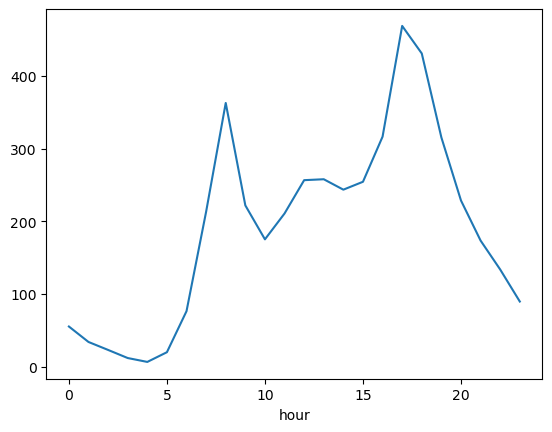

In [14]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()
plt.show()

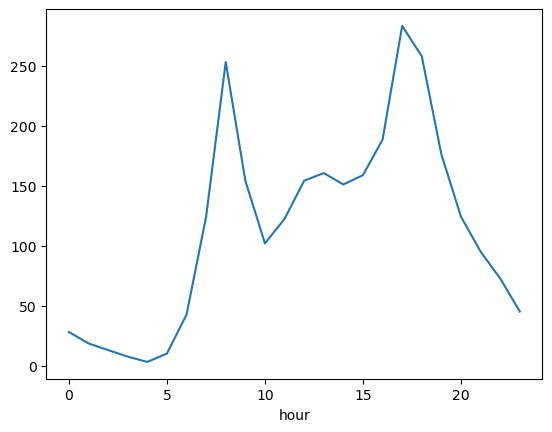

In [15]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos
b_s1=bikes[bikes['season']==1]
b_s1.groupby('hour').total.mean().plot()
plt.show()

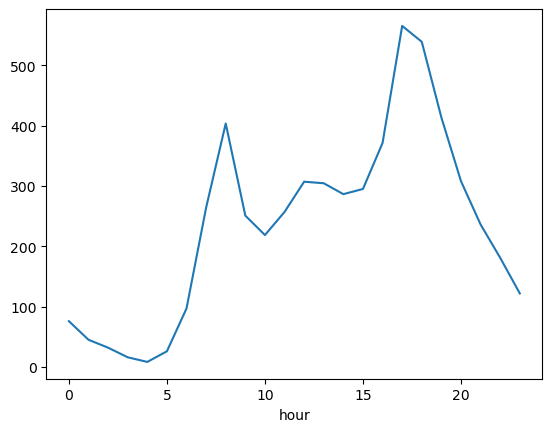

In [16]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
b_s3=bikes[bikes['season']==3]
b_s3.groupby('hour').total.mean().plot()
plt.show()

### Punto 2- ÁNALISIS
- En las tres imagenes se observa un preservación de patrón (misma forma de la curva): Pico moderado (alrededor de las 8-9am), pico alto (alrededor de las 17-18pm) y un descanso natural (entre las 0-5am). Esto nos indica que el uso de la bicicleta no depende de la estación, sino que depende de la rutina humana. 
- Lo que varía en las tres imágenes es el volumen, los picos según la estacionalidad. En invierno (Season 01) el pico apenas supera los 250 unidades en promedio. Mientras que en verano, el pico supera los 500 unidades en promedio. Podemos decir que las estaciones son un potenciador o mitigador de la demanda.


### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [114]:
# Celda 3
from sklearn.model_selection import train_test_split

# 1. Transformación de variables categóricas 
season_dummies=pd.get_dummies(bikes['season'],prefix='season', drop_first=True)
bikes_1=pd.concat([bikes,season_dummies],axis=1)


variables_predictoras=['season_2', 'season_3', 'season_4','hour']
y=bikes_1['total']
x=bikes_1[variables_predictoras]

# Dividir en train y test
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.33, random_state=42)

# 2. Regresión lineal
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

# 3. Coeficientes
print('Intercepto (beta 0):',model.intercept_)
print('Coeficientes:', dict(zip(variables_predictoras, model.coef_)))

# 4. Evalaución (calcular el MSE)
from sklearn.metrics import mean_squared_error
y_pred_lineal=model.predict(x_test)
mse_regresion_lineal=mean_squared_error(y_test,y_pred_lineal)

print(f'MSE de la regresión lineal es {mse_regresion_lineal:.2f}')


Intercepto (beta 0): -7.671323432608062
Coeficientes: {'season_2': 99.03019820822733, 'season_3': 115.71036692432523, 'season_4': 90.63770540672908, 'hour': 10.687677598240015}
MSE de la regresión lineal es 25366.61


### Parte 3- ANÁLISIS
Interpretación de coeficientes
- El número de rentas a la media noche en invierno es casi nulo (-7 bicicletas), 
- Hour: por cada hora que pasa las rentas en promedio aumentan en 10.68 unidades, manteniendo la estación constante. 
- season_3: en verano se rentan 115.71 más por hora que en invierno. Es la estación con mayor impacto positivo.
- season_2,  season_4 : en estación 2 se rentan 99 bicicletas más que en invierno. En estación 4 se rentan 90 bicicletas más que en invierno.

Limitaciones:
- No detecta las pendientes positivas ni negativas. Es incapaz de detectar los picos
- Las predicciones están fuera de rango, como el intercepto es negativo el modelo está prediciendo valores imposibles, menos de cero bicicletas en las madrugadas de invierno.
- Aunque el comportamiento horario es consistente en todas las estaciones, la magnitud del cambio no es constante. La regresión lineal tiene la limitación de aplicar un coeficiente estacional fijo (ej. +115.71 en verano) para todas las horas, ignorando que el impacto de la estación es mucho más fuerte en las horas pico que en las madrugadas.


### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [162]:
# Celda 4
# Variables
variables_predictoras_tree=['season','hour']
x_tree=bikes[variables_predictoras_tree]
y_tree=bikes['total']


# Dividir en train y test
x_train_tree, x_test_tree, y_train_tree, y_test_tree=train_test_split(x_tree,y_tree, test_size=0.33, random_state=42)

# 1. CALCULAR EL MSE
def mse(y):
    if len(y) == 0:
        return 0
    y = np.asarray(y, dtype=float)
    return np.mean((y - np.mean(y))**2)
        

# 2. CALCULAR LA REDUCCIÓN DEL MSE
def mse_impurity(X_col, y, split):
    
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]
    
    n_l = y_l.shape[0]
    n_r = y_r.shape[0]

    if n_l == 0 or n_r == 0:
        return 0
    
    mse_y = mse(y)
    mse_l = mse(y_l)
    mse_r = mse(y_r)
    
    mse_reduccion = mse_y - (n_l / (n_l + n_r) * mse_l + n_r / (n_l + n_r) * mse_r)
    
    return mse_reduccion

# 3. CALCULAR EL MEJOR SPLIT Y EL PUNTO DE CORTE
def best_split(X, y, num_pct=10):
    
    features = range(X.shape[1])
    
    mejor = [0, 0, 0]  # j, split, gain
    
     
    for j in features:
        
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]
        
        
        for split in splits:
            gain = mse_impurity(X.iloc[:, j], y, split)
                        
            if gain > mejor[2]:
                mejor = [j, split, gain]
    
    return mejor


# 4. CRECIMIENTO RECURSIVO DEL ÁRBOL 
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    
    
    if X.shape[0] == 1:
        tree = dict(y_pred=float(y.iloc[0]), level=level, split=-1, n_samples=1, gain=0)
        return tree
        
    j, split, gain = best_split(X, y, num_pct)
    
    
    y_pred = float(y.mean())
       
    tree = dict(y_pred=y_pred, level=level, split=-1, n_samples=X.shape[0], gain=gain)
    
    
    if gain < min_gain:
        return tree
    if max_depth is not None:
        if level >= max_depth:
            return tree   
    
    # Continuar creando la partición
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]

    if X_l.shape[0] == 0 or X_r.shape[0] == 0:     #
        return tree
        
    tree['split'] = [j, split]

    
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    
    return tree


arbol_manual=tree_grow(x_train_tree, y_train_tree, level=0, min_gain=0.001, max_depth=3, num_pct=10)
arbol_manual

{'y_pred': 191.86178527354997,
 'level': 0,
 'split': [1, 8.0],
 'n_samples': 7293,
 'gain': 9397.901194415062,
 'sl': {'y_pred': 55.10168101681017,
  'level': 1,
  'split': [1, 7.0],
  'n_samples': 2439,
  'gain': 3606.6255616898616,
  'sl': {'y_pred': 32.69640354974311,
   'level': 2,
   'split': [1, 6.0],
   'n_samples': 2141,
   'gain': 341.76212826957226,
   'sl': {'y_pred': 25.147138964577657,
    'level': 3,
    'split': -1,
    'n_samples': 1835,
    'gain': 170.1430442683519},
   'sr': {'y_pred': 77.9673202614379,
    'level': 3,
    'split': -1,
    'n_samples': 306,
    'gain': 355.8803667310731}},
  'sr': {'y_pred': 216.0738255033557,
   'level': 2,
   'split': [0, 2.0],
   'n_samples': 298,
   'gain': 2271.4013318297402,
   'sl': {'y_pred': 133.89333333333335,
    'level': 3,
    'split': -1,
    'n_samples': 75,
    'gain': 0},
   'sr': {'y_pred': 243.71300448430495,
    'level': 3,
    'split': -1,
    'n_samples': 223,
    'gain': 88.623521032383}}},
 'sr': {'y_pred': 2

In [166]:
def predict_manual(tree, row):
    if tree['split'] == -1:
        return tree['y_pred']
    
    j, split_value = tree['split']
    
   
    if row.iloc[j] < split_value:
        return predict_manual(tree['sl'], row)
    else:
        return predict_manual(tree['sr'], row)

# Predicciones para todo el set de prueba
x_test_tree = x_test_tree[variables_predictoras_tree]
y_pred_tree = x_test_tree.apply(lambda row: predict_manual(arbol_manual, row), axis=1)

# Calcularmos el mse
MSE_manual_tree= ((y_test_tree - y_pred_tree)**2).mean()

print(f'MSE del árbol manual: {MSE_manual_tree:.3f}')

MSE del árbol manual: 17833.448


### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

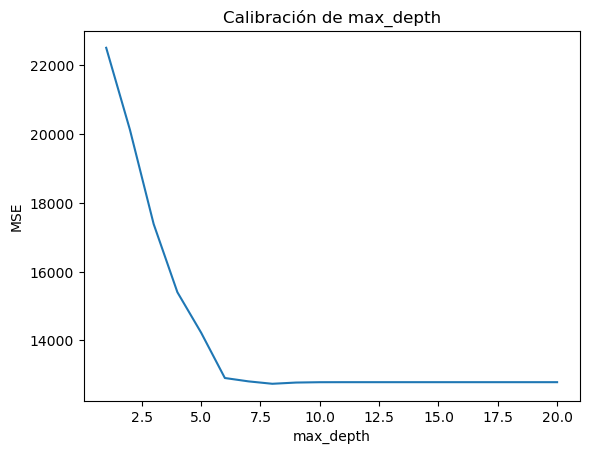

La profundidad óptima calibrada es: 8
MSE del árbol de decisiones con Sklearn (calibrado): 13659.49
Estadísticas del MSE en Cross-Validation:
count       10.000000
mean     12739.450094
std       1078.428986
min      10691.333598
25%      12068.954286
50%      12753.196413
75%      13567.064462
max      14167.698180
dtype: float64


,feature,importance
0,season,0.135458
1,hour,0.864542


In [122]:
# Celda 5
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

#1. DEFINICIÓN DE LAS VARIABLES 
# Utilizaremos las mismas del ejercicio anterior x_train_tree, x_test_tree, y_train_tree, y_test_tree

# 2. CALIBRACIÓN
max_depth_range = range(1, 21)
mse_scores = []

for depth in max_depth_range:
    clf = DecisionTreeRegressor(max_depth=depth, random_state=42)
    mse_s = cross_val_score(clf, x_train_tree, y_train_tree, cv=10, scoring='neg_mean_squared_error')
    mse_scores.append(-mse_s.mean())

plt.plot(max_depth_range, mse_scores)
plt.xlabel('max_depth')
plt.ylabel('MSE')
plt.title('Calibración de max_depth')
plt.show()

best_depth = max_depth_range[np.argmin(mse_scores)]
print(f"La profundidad óptima calibrada es: {best_depth}")


# 3. ENTRENAMIENTO
tree_reg = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
tree_reg.fit(x_train_tree, y_train_tree)

# 4. EVALUACIÓN (TEST)
y_pred_tree = tree_reg.predict(x_test_tree)
mse_tree_sklearn = mean_squared_error(y_test_tree, y_pred_tree)
print(f"MSE del árbol de decisiones con Sklearn (calibrado): {mse_tree_sklearn:.2f}")

# 5. CROSS VALIDATION
scores = cross_val_score(tree_reg, x_train_tree, y_train_tree, cv=10, scoring='neg_mean_squared_error')
mse_scores = -scores
print("Estadísticas del MSE en Cross-Validation:")
print(pd.Series(mse_scores).describe())

# IMPORTANCIA DE LAS VARIABLES
pd.DataFrame({'feature':variables_predictoras_tree, 'importance':tree_reg.feature_importances_}).sort_values('importance')




### Punto 5- ANÁLISIS
1. Desempeño del modelo 

Para validar la robustez del modelo, se implementó una Validación Cruzada (10-fold Cross-Validation) sobre el conjunto de entrenamiento. El MSE promedio obtenido fue de 12,739.45, con una desviación estándar de 1,078.43. Estos resultados confirman que el modelo es estable y generaliza correctamente ante diferentes subconjuntos de datos.
Además, el análisis de importancia de variables revela que la hora (hour) es el predictor dominante con un peso del 86.4%, mientras que la estación (season) aporta el 13.5% restante.

2. Comparación con el desempeño del ejercicio 3

Al comparar los resultados, se evidencia una mejora significativa en la capacidad predictiva del Árbol de Decisión frente a la Regresión Lineal:
- Regresión Lineal (Punto 3): MSE de 25,366.61
- Árbol de Decisión (Punto 5): MSE de 13,659.49

El Árbol de Decisión logró reducir el MSE en aproximadamente un 46% respecto a la Regresión Lineal. Porque la demanda de bicicletas presenta comportamientos no lineales y picos estacionales/horarios. La Regresión Lineal intenta ajustar una línea recta (asumiendo que cada hora adicional aumenta la demanda de forma constante en 10.68 unidades), el Árbol de Decisión logra segmentar los datos en reglas lógicas que capturan mucho mejor los cambios bruscos en la demanda durante las horas pico y las diferentes estaciones.



## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [128]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [130]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

0.5

In [132]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [144]:
# Celda 6
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

# --- 1. REGRESIÓN LOGÍSTICA ---
# CREACIÓN DEL MODELO 
log_reg=LogisticRegression(max_iter=10000)
log_reg.fit(X_train,y_train)

# PREDICCIONES
y_pred_log=log_reg.predict(X_test)


# --- 2. ÁRBOL DE DECISIONES ---
# A. CALIBRACIÓN
param_grid={'max_depth': range(1,21)}
tree_cl=DecisionTreeClassifier(random_state=42)

grid_search=GridSearchCV(tree_cl, param_grid, cv=5, scoring='f1')

#B. CREACIÓN DEL MODELO CALIBRADO
grid_search.fit(X_train, y_train)
best_tree=grid_search.best_estimator_

# C. PREDICCIONES
y_pred_tree=best_tree.predict(X_test)

# --- 3. DESEMPEÑO --- 
print(f'Mejor profundidad para el árbol: {grid_search.best_params_['max_depth']}\n')

models={ "Regresión Logística": y_pred_log,
        " Árbol de decisión": y_pred_tree}

for md,pred in models.items():
    print(f'---{md}---')
    print(f'Acurracy:{accuracy_score(y_test,pred):.4f}')
    print(f'F1 score:{f1_score(y_test,pred):.4f}') 

Mejor profundidad para el árbol: 4

---Regresión Logística---
Acurracy:0.6147
F1 score:0.5947
--- Árbol de decisión---
Acurracy:0.6513
F1 score:0.6345


### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [150]:
# Celda 7
from sklearn.utils import resample

# 1. CONFIGURACIÓN DEL ENSAMBLE
n_estimators = 100
seeds = range(300) 
all_predictions = np.zeros((X_test.shape[0], 300))

# 2. CREACIÓN Y ENTRENAMIENTO DE LOS  300 MODELOS (BOOSTRAPPING)
for i in range(300):
    X_boot, y_boot = resample(X_train, y_train, random_state=seeds[i])
    
    if i < 100:
        # Primeros 100: Árboles con max_depth (4 igual que el ejercicio anterior)
        model = DecisionTreeClassifier(max_depth=4, random_state=seeds[i])
    elif i < 200:
        # Segundos 100: Árboles con min_samples_leaf de elección 
        model = DecisionTreeClassifier(min_samples_leaf=5, random_state=seeds[i])
    else:
        # Últimos 100: Regresiones Logísticas
        model = LogisticRegression(max_iter=1000, random_state=seeds[i])
    
    model.fit(X_boot, y_boot)
    all_predictions[:, i] = model.predict(X_test)

# 3.EVALUACIÓN DE MODELOS INDEPENDIENTES
y_pred_tipo1 = (all_predictions[:, 0:100].mean(axis=1) >= 0.5).astype(int)
y_pred_tipo2 = (all_predictions[:, 100:200].mean(axis=1) >= 0.5).astype(int)
y_pred_tipo3 = (all_predictions[:, 200:300].mean(axis=1) >= 0.5).astype(int)

tipos = ["Árboles (max_depth)", "Árboles (min_samples_leaf)", "Regresiones Logísticas"]
preds_tipos = [y_pred_tipo1, y_pred_tipo2, y_pred_tipo3]

for nombre, pred in zip(tipos, preds_tipos):
    print(f"--- {nombre} ---")
    print(f"Accuracy: {accuracy_score(y_test, pred):.4f} | F1: {f1_score(y_test, pred):.4f}")

#  4. EVALUACIÓN DEL ENSAMBLE TOTAL 
y_pred_ensamble = (all_predictions.mean(axis=1) >= 0.5).astype(int)
print("--- ENSAMBLE TOTAL (300 Modelos) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ensamble):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_ensamble):.4f}")


--- Árboles (max_depth) ---
Accuracy: 0.6467 | F1: 0.6385
--- Árboles (min_samples_leaf) ---
Accuracy: 0.6500 | F1: 0.6530
--- Regresiones Logísticas ---
Accuracy: 0.6160 | F1: 0.6033
--- ENSAMBLE TOTAL (300 Modelos) ---
Accuracy: 0.6400
F1-Score: 0.6301


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [152]:
# Celda 8
# --- 1. Obtener los índices de las muestras OOB para cada modelo ---
errors_oob = np.zeros(300)
n_samples = X_train.shape[0]
indices = np.arange(n_samples)

# Usamos los mismos modelos/semillas del punto 7 para ser consistentes
for i in range(300):
    train_indices = resample(indices, replace=True, n_samples=n_samples, random_state=seeds[i])
    oob_indices = list(set(indices) - set(train_indices))
    
    X_boot, y_boot = X_train.iloc[train_indices], y_train.iloc[train_indices]
    
    if i < 100:
        model = DecisionTreeClassifier(max_depth=4, random_state=seeds[i])
    elif i < 200:
        model = DecisionTreeClassifier(min_samples_leaf=5, random_state=seeds[i])
    else:
        model = LogisticRegression(max_iter=1000, random_state=seeds[i])
    
    model.fit(X_boot, y_boot)
    
    # --- 2. Estimación del Error OOB ---
    y_pred_oob = model.predict(X_train.iloc[oob_indices])
    errors_oob[i] = 1 - accuracy_score(y_train.iloc[oob_indices], y_pred_oob)

# --- 3. Obtención de pesos ALPHA ---
weights_alpha = (1 - errors_oob) / (1 - errors_oob).sum()

# --- 4. Ponderación de las predicciones (usando X_test) ---
weighted_sum = (all_predictions * weights_alpha).sum(axis=1)
y_pred_weighted_oob = (weighted_sum >= 0.5).astype(int)

# --- 5. Evaluación ---
print("--- ENSAMBLE CON VOTACIÓN PONDERADA (PESOS OOB) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_weighted_oob):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_weighted_oob):.4f}")

--- ENSAMBLE CON VOTACIÓN PONDERADA (PESOS OOB) ---
Accuracy: 0.6393
F1-Score: 0.6297


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

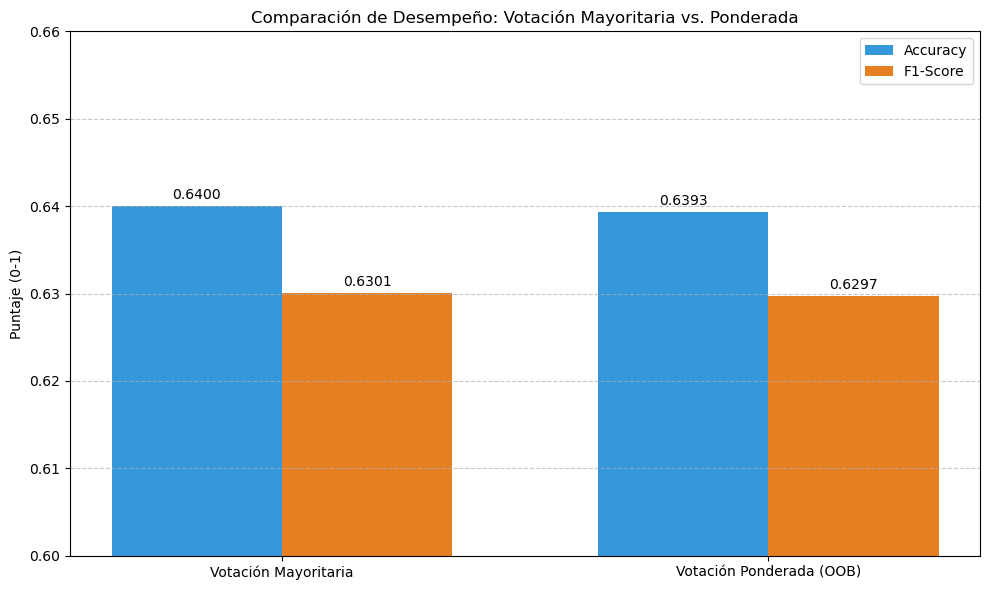

In [154]:
# Celda 9
import matplotlib.pyplot as plt
import numpy as np

# Datos extraídos de tus resultados
metodologias = ['Votación Mayoritaria', 'Votación Ponderada (OOB)']
accuracy_vals = [0.6400, 0.6393]
f1_vals = [0.6301, 0.6297]

x = np.arange(len(metodologias))  # Localización de las etiquetas
width = 0.35  # Ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

# Crear las barras
rects1 = ax.bar(x - width/2, accuracy_vals, width, label='Accuracy', color='#3498db')
rects2 = ax.bar(x + width/2, f1_vals, width, label='F1-Score', color='#e67e22')

# Añadir etiquetas y títulos
ax.set_ylabel('Puntaje (0-1)')
ax.set_title('Comparación de Desempeño: Votación Mayoritaria vs. Ponderada')
ax.set_xticks(x)
ax.set_xticklabels(metodologias)
ax.set_ylim(0.6, 0.66) # Ajustamos el límite para notar la diferencia
ax.legend()

# Función para añadir etiquetas sobre las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 puntos de desplazamiento vertical
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Punto 9- ANÁLISIS
Comparación de los resultados

Votación Mayoritaria simple obtuvo resultados ligeramente mejores (apenas por un margen de 0.0007 en Accuracy) que la Votación Ponderada por OOB. Esto se da porque los árboles de decisiones tuvieron un desempeño individual semejante entre estos dos y superior a la regresión logística. Cuando los modelos son parecidos en calidad, ponderar no mejora significativamente el rendimiento.

Ventajas y desventajas
A. Votación mayoritaria
Ventajas:
- Simplicidad: más fácil y menos costoso
- Robustez: como se tratan los modelos por igual,se protege contra los casos donde el entrenamiento tuvo un desempeño bueno, pero falle en los datos reales

Desventajas
- Le da el mismo peso al voto de un modelo preciso que la de uno mediocre.

B. Votación ponderada
Ventajas: 
- Jerarquía de importancia: promueve a los modelos con mejor desempeño y silencia a los modelos con más errores.
- Uso OOB: usa datos no vistos para evitar el sobreajuste

Desventajas:
- Complejidad
- Riesgo de sesgo: Si los pesos se calculan sobre una muestra que no es representativa, el ensamble puede volverse dependiente de un solo tipo de modelo, perdiendo la diversidad que hace fuerte al ensamble.


Aunque la Votación Ponderada es técnicamente más sofisticada, en este experimento la Votación Mayoritaria demostró ser suficiente y ligeramente superior. Esto sugiere que la diversidad aportada por los 300 modelos es lo suficientemente sólida para que el promedio simple de sus votos capture la tendencia de popularidad de las noticias sin necesidad de ajustes adicionales por peso.


